# L15d: Mixed-Sugar Fermentation with a Maintained Solver

This lab adapts the 2024 _Klebsiella oxytoca_ mixed-sugar model to practice solver selection, physical checks, and interpretation of coupled nonlinear dynamics.

> **Learning objectives**
>
> - Represent coupled substrate, enzyme, and biomass balances.
> - Solve the model with a maintained adaptive ODE algorithm.
> - Check physical directionality and nonnegativity.
> - Compare solver agreement without confusing it with model validation.


## Setup


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


## State and parameter contract

The five states are glucose-like substrate `S1`, xylose-like substrate `S2`, their corresponding inducible enzymes `E1` and `E2`, and biomass `C`. Cybernetic allocation variables distribute enzyme synthesis and metabolic activity between the two substrates.


In [2]:
parameters = fermentation_parameters()
initial_state = [
    0.5,
    2.5,
    0.90 * parameters.maximum_enzyme[1],
    0.18 * parameters.maximum_enzyme[2],
    4e-3,
]
DataFrame(
    state = ["S1", "S2", "E1", "E2", "C"],
    initial_value = initial_state,
)


Row,state,initial_value
,String,Float64
1,S1,0.5
2,S2,2.5
3,E1,0.00079646
4,E2,0.000206897
5,C,0.004


## Solve with an adaptive library method


In [3]:
solution = library_integrate(
    fermentation_rhs,
    initial_state,
    (0.0, 10.0);
    p = parameters,
    saveat = 0.05,
)
DataFrame(
    state = ["S1", "S2", "E1", "E2", "C"],
    initial = vec(solution.u[1, :]),
    final = vec(solution.u[end, :]),
    change = vec(solution.u[end, :] - solution.u[1, :]),
)


Row,state,initial,final,change
,String,Float64,Float64,Float64
1,S1,0.5,1.21234e-13,-0.5
2,S2,2.5,1.76998e-12,-2.5
3,E1,0.00079646,0.000113629,-0.000682831
4,E2,0.000206897,0.000997666,0.00079077
5,C,0.004,1.514,1.51


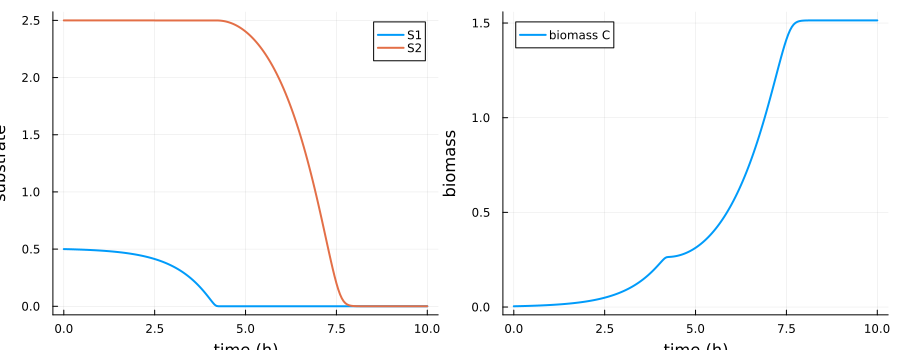

In [4]:
substrate_plot = plot(
    solution.t,
    solution.u[:, 1:2];
    label = ["S1" "S2"],
    linewidth = 2,
    xlabel = "time (h)",
    ylabel = "substrate",
)
biomass_plot = plot(
    solution.t,
    solution.u[:, 5];
    label = "biomass C",
    linewidth = 2,
    xlabel = "time (h)",
    ylabel = "biomass",
)
plot(substrate_plot, biomass_plot; layout = (1, 2), size = (900, 350))


## Physical and numerical checks


In [5]:
checks = (
    finite = all(isfinite, solution.u),
    nonnegative = minimum(solution.u) >= -1e-10,
    substrate_1_consumed = solution.u[end, 1] < initial_state[1],
    substrate_2_consumed = solution.u[end, 2] < initial_state[2],
    biomass_increased = solution.u[end, 5] > initial_state[5],
)
checks


(finite = true, nonnegative = true, substrate_1_consumed = true, substrate_2_consumed = true, biomass_increased = true)

## Compare a transparent fixed-step method


In [6]:
euler = explicit_euler(
    fermentation_rhs,
    initial_state,
    (0.0, 10.0),
    0.01;
    p = parameters,
)
reference_on_euler_grid = library_integrate(
    fermentation_rhs,
    initial_state,
    (0.0, 10.0);
    p = parameters,
    saveat = 0.01,
)
(maximum_state_error = maximum(abs.(euler.u .- reference_on_euler_grid.u)),
    minimum_euler_state = minimum(euler.u))


(maximum_state_error = 0.018667919776175657, minimum_euler_state = 3.136094533272067e-15)

In [7]:
@testset "mixed-sugar fermentation" begin
    @test all(values(checks))
    @test size(solution.u, 2) == 5
    @test maximum(abs.(euler.u .- reference_on_euler_grid.u)) < 0.05
    @test_throws DimensionMismatch fermentation_rhs(zeros(4), 0.0, parameters)
end


Test Summary:            | Pass  Total  Time
mixed-sugar fermentation |    4      4  0.5s


Test.DefaultTestSet("mixed-sugar fermentation", Any[], 4, false, false, true, 1.786458913372923e9, 1.786458913879525e9, false, "In[7]", Random.Xoshiro(0x713d3620e80fb6a2, 0x20dba6de5ff5d362, 0x44bde50856c308f5, 0x75af56f8ba0174ab, 0x635104b2cfca8e3e))

## Interpretation and limits

Solver agreement supports the numerical calculation. It does not establish parameter identifiability, biological completeness, or agreement with experiments. Those claims require data, uncertainty analysis, and a documented calibration/validation design.
